In [1]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb
import ipywidgets as widgets
from IPython.display import display
import gc
import time
import sklearn

# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

from IPython.display import Image, display
import glob

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)
from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# HMM-related imports from JAX, Dynamax, and TensorFlow Probability
from functools import partial
import jax.numpy as jnp
import jax.random as jr
from dynamax.hidden_markov_model import GaussianHMM
from dynamax.utils.utils import find_permutation

# Additional HMM variants and plotting utilities from Dynamax
from dynamax.hidden_markov_model import (
    DiagonalGaussianHMM,
    SphericalGaussianHMM,
    SharedCovarianceGaussianHMM
)

from dynamax.utils.plotting import CMAP, COLORS, white_to_color_cmap

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


In [2]:
root = Path("/root/capsule/data/dynamicrouting_datacube")

example_session_ids = [
                        "759434_2025-02-04", "713655_2024-08-09", "743199_2024-12-05", 
                        "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24",
                        "667252_2023-09-28", "715710_2024-07-16", "708016_2024-04-29",
                    ]


session_id = example_session_ids[1] #session 4? mouse 4?

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb.zarr"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr


In [3]:
session = pynwb.read_nwb(nwb_path)

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


In [4]:
# QC thresholds from Shawn 

units_table = session.units.to_dataframe()


MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better
MAX_ACTIVITY_DRIFT = 0.2 # lower is better, moderate threshold

good_units = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO) & 
    (units_table.activity_drift < MAX_ACTIVITY_DRIFT)
]
print('%d of %d units passed quality control' % (len(good_units), len(units_table)))

1365 of 3577 units passed quality control


In [5]:
trials = session.trials[:]
trials.head()

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2403.42415,2408.92875,2403.42415,2404.89204,2404.93261,2405.43261,2405.00879,2405.92623,2405.47583,2405.46553,2405.49254,2405.953890,2408.956420,sound1,NaN,0,aud,0,0.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
1,2409.89623,2415.40125,2409.89623,2411.36411,2411.40501,2411.90501,2411.48088,2412.39832,2411.74797,2411.73257,2411.76447,2412.426005,2415.428515,sound1,NaN,0,aud,1,1.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
2,2417.98632,2423.49098,2417.98632,2419.45423,2419.49515,2419.99515,2419.57102,2420.48843,2420.03805,2420.03365,2420.05473,2420.516120,2423.518630,sound1,NaN,0,aud,2,2.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
3,2429.22911,2434.73372,2429.22911,2430.69701,2430.73779,2431.23779,2430.81378,2431.73118,2431.43094,2431.43076,2431.44765,2431.758880,2434.761390,sound1,NaN,0,aud,3,3.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
4,2435.43427,2440.93889,2435.43427,2436.90215,2436.94313,2437.44313,2437.01895,2437.93632,2437.60277,2437.60187,2437.61948,2437.964090,2440.966610,sound1,NaN,0,aud,4,4.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,True,True,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False


In [6]:
good_units.head()

,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,d_prime,decoder_label,decoder_probability,default_qc,device_name,drift_mad,drift_ptp,drift_std,electrode_group_name,exp_decay,firing_range,firing_rate,half_width,is_not_drift,is_qc_pass,isi_violations_count,isi_violations_ratio,isolation_distance,l_ratio,location,nn_hit_rate,nn_miss_rate,num_negative_peaks,num_positive_peaks,num_spikes,peak_channel,peak_electrode,peak_to_valley,peak_trough_ratio,presence_ratio,recovery_slope,repolarization_slope,rp_contamination,rp_violations,silhouette,sliding_rp_violation,snr,spike_amplitudes,spread,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,0.093258,297.245514,0.000016,NaN,NaN,196.560000,6150.0,3825.0,4850.0,3,5.249897,sua,0.85,True,20097906812,7.515987,24.548646,3.918794,probeA,0.033764,11.0,4.390704,0.000167,True,True,3.0,0.006771,139.091580,0.032691,AV,0.865692,0.009278,1,1,33636.0,5,5,0.000423,-0.501085,1.0,-180857.379447,1.266800e+06,0.006794,2.0,0.154244,0.01,11.379719,"[-226.98, -212.93999, -159.12, -133.37999, -23...",80.0,AV,0.022535,0.00003,0.0,713655_2024-08-09_A-3,NaN,NaN,"[21.589898466019914, 25.376921105508842, 26.38...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x13965...
4,0.136946,102.880402,0.000222,0.514950,0.560272,56.159996,6100.0,3800.0,4850.0,4,3.126732,sua,0.63,False,20097906812,NaN,NaN,NaN,probeA,0.028388,3.0,0.562218,0.000413,False,False,2.0,0.275315,74.687850,1.688826,AV,0.315534,0.013454,1,2,4307.0,7,7,0.000393,-0.827439,1.0,-77300.768984,4.390522e+05,0.000000,0.0,0.048807,0.23,3.235930,"[-53.82, -53.82, -46.8, -88.92, -100.619995, -...",100.0,AV,0.039703,0.00000,0.0,713655_2024-08-09_A-4,NaN,NaN,"[20.275168845237403, 20.52226814747514, 20.788...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x13965...
6,0.011568,202.966923,0.000046,0.164086,0.092949,152.099990,6100.0,3800.0,4850.0,8,4.584082,sua,0.92,True,20097906812,6.309103,26.413326,7.447258,probeA,0.030063,5.4,5.395960,0.000107,True,True,24.0,0.035866,91.654422,0.629299,AV,0.746764,0.004624,1,1,41337.0,7,7,0.000303,-0.339591,1.0,-88194.383580,1.478454e+06,0.031891,14.0,0.139419,0.03,8.734913,"[-16.38, -77.21999, -44.46, -79.56, -65.52, -6...",100.0,AV,0.025522,0.00000,0.0,713655_2024-08-09_A-8,NaN,NaN,"[20.5297681262966, 20.66936773209339, 20.76706...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x13965...
8,0.180385,100.428110,0.000044,0.323350,0.350918,67.860000,6100.0,3800.0,4850.0,10,2.847326,sua,0.90,False,20097906812,11.547881,35.396378,11.663687,probeA,0.030830,20.6,6.119782,0.000190,False,False,20.0,0.023236,97.845411,0.381415,AV,0.500809,0.027082,1,1,46882.0,7,7,0.000473,-0.426310,1.0,-46438.525464,4.006242e+05,0.022918,13.0,0.077436,0.03,4.056651,"[-56.159996, -79.56, -65.52, -100.619995, -58....",100.0,AV,0.029222,0.00000,0.0,713655_2024-08-09_A-10,NaN,NaN,"[20.34430198335167, 20.457268331022476, 20.463...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x13965...
9,0.056400,118.881348,0.000117,0.322816,0.272172,77.219990,6100.0,3750.0,4850.0,11,3.484575,sua,0.84,True,20097906812,6.121948,24.155724,7.176850,probeA,0.028458,9.2,5.135933,0.000147,True,True,52.0,0.085777,78.991316,2.709647,AV,0.280277,0.009817,1,1,39345.0,10,10,0.000360,-0.371568,1.0,-48506.109572,4.858833e+05,0.088000,34.0,0.051470,0.08,4.293262,"[4.68, -21.06, -32.76, 0.0, -2.34, -11.7, -37....",120.0,AV,0.029788,0.00000,0.0,713655_2024-08-09_A-11,NaN,NaN,"[20.66703440534894, 20.68156769764297, 21.0538...","[[20.259535556049556, 7680.968703144603]]",probeA pynwb.ecephys.ElectrodeGroup at 0x13965...


In [15]:
good_units.location.unique()

<StringArray>
[        'AV',         'AD',      'MOs6a',      'MOp6a',       'MOp5',
     'MOp2/3',       'SSs4',       'SSs5',   'SSp-bfd4', 'SSp-bfd2/3',
      'PERI5',       'ECT5',      'ECT6a',      'TEa6a',     'AUDv6a',
     'AUDp6a',      'AUDp5',     'AUDpo5',       'TEa5',       'TEa4',
     'TEa2/3',   'VISli2/3',        'LSr',         'CP',      'MOp6b',
        'LSc',     'ACAd6a',       'MOs5',     'MOs2/3']
Length: 29, dtype: str

In [7]:
key = 'AUD'


area_units = good_units[good_units['location'].str.contains(key)]

In [30]:
area_units.head()

,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,cluster_id,d_prime,decoder_label,decoder_probability,default_qc,device_name,drift_mad,drift_ptp,drift_std,electrode_group_name,exp_decay,firing_range,firing_rate,half_width,is_not_drift,is_qc_pass,isi_violations_count,isi_violations_ratio,isolation_distance,l_ratio,location,nn_hit_rate,nn_miss_rate,num_negative_peaks,num_positive_peaks,num_spikes,peak_channel,peak_electrode,peak_to_valley,peak_trough_ratio,presence_ratio,recovery_slope,repolarization_slope,rp_contamination,rp_violations,silhouette,sliding_rp_violation,snr,spike_amplitudes,spread,structure,sync_spike_2,sync_spike_4,sync_spike_8,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrode_group
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1402,0.097930,61.368807,0.000284,0.305241,0.206076,42.12000,8800.0,2025.0,1600.0,485,3.797888,sua,0.63,True,18005120322,NaN,NaN,NaN,probeC,0.023004,2.09,0.693401,0.000213,True,True,0.0,0.000000,91.634570,1.085430,VISli2/3,0.218841,0.004674,1,1,5312.0,317,1085,0.000613,-0.408245,1.000000,-30862.743261,172314.416442,0.000000,0.0,0.054983,0.160,4.191726,"[-51.48, -23.4, -32.76, -18.72, -9.36, -37.44,...",120.0,VISli,0.070407,0.000000,0.00000,713655_2024-08-09_C-485,NaN,NaN,"[20.589461972238205, 41.39502381019862, 41.465...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x13977...
1404,0.102882,156.503853,0.000026,0.114037,0.054912,121.67999,8800.0,2025.0,1600.0,487,5.898717,sua,0.94,False,18005120322,5.212878,18.040039,5.880413,probeC,0.023648,9.40,12.703005,0.000203,False,False,7.0,0.001888,126.873730,0.185726,VISli2/3,0.646377,0.004231,1,1,97315.0,317,1085,0.000607,-0.331552,1.000000,-67386.806010,429737.000283,0.001214,3.0,0.100664,0.005,11.243291,"[-133.37999, -149.76, -149.76, -154.43999, -13...",100.0,VISli,0.070657,0.000113,0.00001,713655_2024-08-09_C-487,NaN,480.232914,"[20.318764637226796, 20.58929530721234, 20.768...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x13977...
1406,0.068492,97.461042,0.000713,0.188367,0.132870,74.88000,8800.0,2000.0,1600.0,489,2.965434,sua,0.66,True,18005120322,NaN,NaN,NaN,probeC,0.021013,1.20,0.321638,0.000170,True,True,1.0,0.420601,97.063054,0.831804,VISli2/3,0.226804,0.005099,1,1,2464.0,321,1089,0.000620,-0.325744,0.992126,-41926.764000,280273.319787,0.000000,0.0,0.050857,NaN,7.012448,"[-35.1, -42.12, -58.499996, -42.12, -37.44, -3...",100.0,VISli,0.071429,0.000406,0.00000,713655_2024-08-09_C-489,631.913922,NaN,"[43.329838095475964, 56.18611152673081, 158.45...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x13977...
1407,0.151396,224.920834,0.000010,0.084387,0.056655,163.79999,8800.0,2000.0,1600.0,490,8.094980,sua,0.87,False,18005120322,4.781740,15.806641,5.128746,probeC,0.034269,9.20,8.484508,0.000193,False,False,2.0,0.001209,158.682531,0.035729,VISli2/3,0.750842,0.001734,1,1,64998.0,318,1086,0.000640,-0.380838,1.000000,-105923.789899,618517.451869,0.001815,2.0,0.144792,0.005,15.639624,"[-135.72, -135.72, -124.02, -140.4, -133.37999...",100.0,VISli,0.070971,0.000123,0.00000,713655_2024-08-09_C-490,NaN,NaN,"[20.332931164425396, 20.412097051711704, 20.41...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys.ElectrodeGroup at 0x13977...
1410,0.098033,66.718061,0.004324,0.323103,0.352569,42.12000,8800.0,1950.0,1600.0,496,2.407661,mua,0.80,True,18005120322,NaN,NaN,NaN,probeC,0.016687,0.40,0.081845,0.000213,True,True,0.0,0.000000,81.349627,2.745540,VISli2/3,0.199662,0.009793,1,1,627.0,323,1091,0.000630,-0.432518,0.976378,-37741.808058,179471.527400,0.000000,0.0,0.026196,NaN,3.264868,"[-21.06, -37.44, -21.06, -18.72, -7.0199995, -...",160.0,VISli,0.057416,0.000000,0.00000,713655_2024-08-09_C-496,1600.000020,NaN,"[24.21505961192002, 40.88619548623001, 42.6568...","[[20.25846523086851, 7680.969046290036]]",probeC pynwb.ecephys

In [8]:
import neural_subspace_real_data as nsr

# --- point the config at your already-loaded DataFrames ---
# EDIT these two lines to your actual variable names:
units_table = good_units      # your QC'd units table (unit_id, spike_times, ...)
behavior_table = trials    # your behavior/trial table (stim_name, rewarded_modality, is_hit, ...)

# sanity check: these must match, or the correct-vs-incorrect comparison
# will silently find nothing (script will also warn you about this)
print(behavior_table["rewarded_modality"].unique())

cfg = dict(nsr.CONFIG)   # defaults are already set up for this exact schema

# EDIT: set the peri-trial window to match your task
# (e.g. baseline before stim_start_time through the end of the response window)
cfg["t_pre_s"] = -0.5      # seconds relative to stim_start_time; negative = before onset
cfg["t_post_s"] = 1.5

# Match Perich et al. 2018: 50 ms bins, sqrt-transformed counts (variance-
# stabilizing transform, Cunningham & Yu 2014), then a non-causal Gaussian
# kernel of "width" 100 ms. We take "width" = standard deviation of the
# kernel (the usual convention when a paper doesn't say FWHM); if they meant
# FWHM instead, the equivalent sigma is 100/2.355 ~= 42.5 ms.
cfg["bin_size_s"] = 0.05
cfg["sqrt_transform"] = True
smooth_sigma_s = 0.100
cfg["smooth_sigma_bins"] = smooth_sigma_s / cfg["bin_size_s"]

cfg["out_dir"] = "/tmp/dr_subspace"   # where figures get saved

results = nsr.run_real_data_analysis(cfg, spike_table=area_units, trial_table=behavior_table)

<StringArray>
['aud', 'vis']
Length: 2, dtype: str
Loaded 515 trials x 173 units.
Binning spike times into per-trial, per-unit spike counts...
Converting spike counts to smoothed firing rates...
Fitting PCA subspace on 13 condition-averaged PSTHs (n_components=3)...
  variance explained by top PCs: [0.284 0.106 0.078]  cumulative: 0.469
Projecting individual single trials into the subspace...
stim='sound1': correct (context-matched hit) n=61, incorrect (context-mismatched false alarm) n=5
stim='vis1': correct (context-matched hit) n=68, incorrect (context-mismatched false alarm) n=9
Done. Figures written to /tmp/dr_subspace/real_subspace_*.png


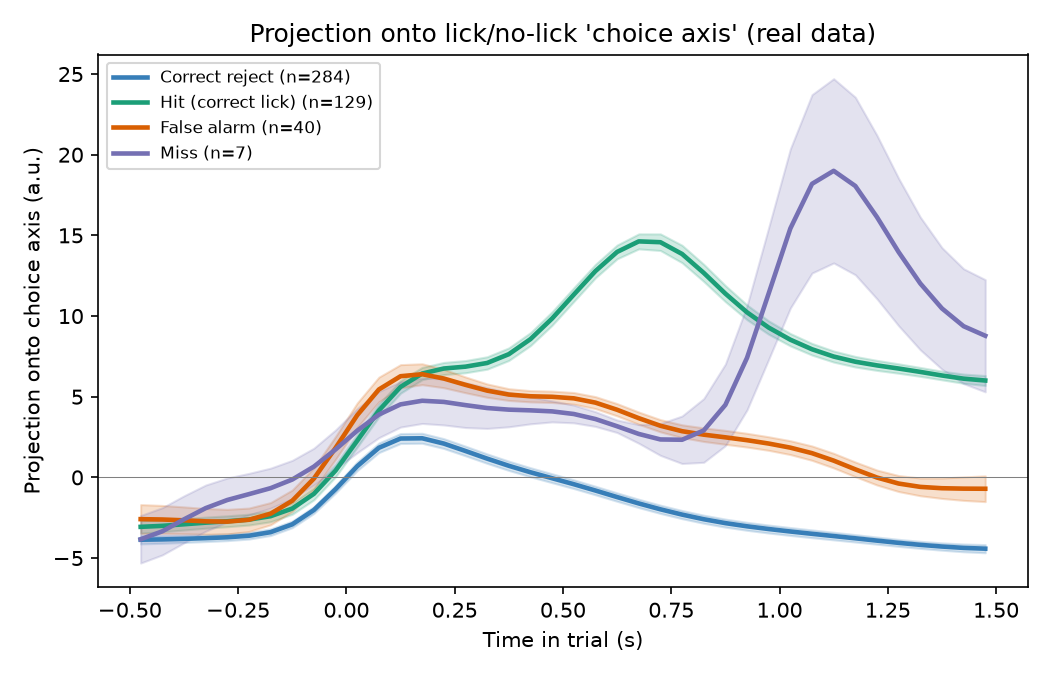

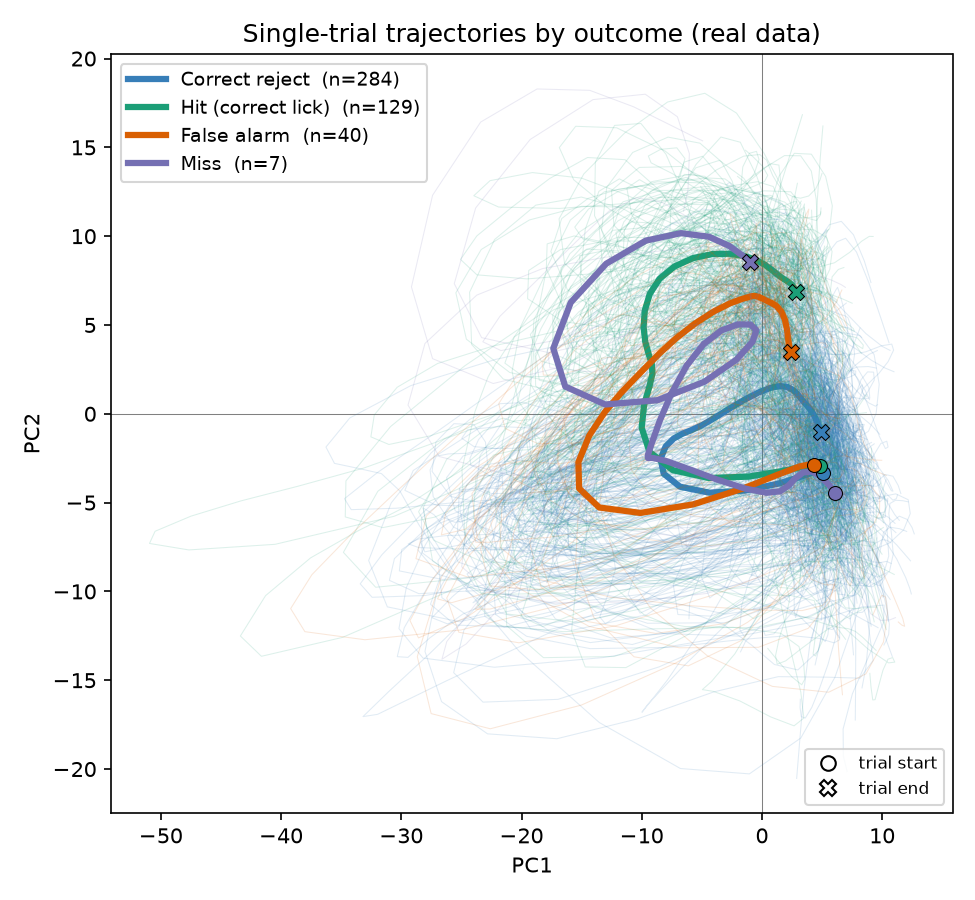

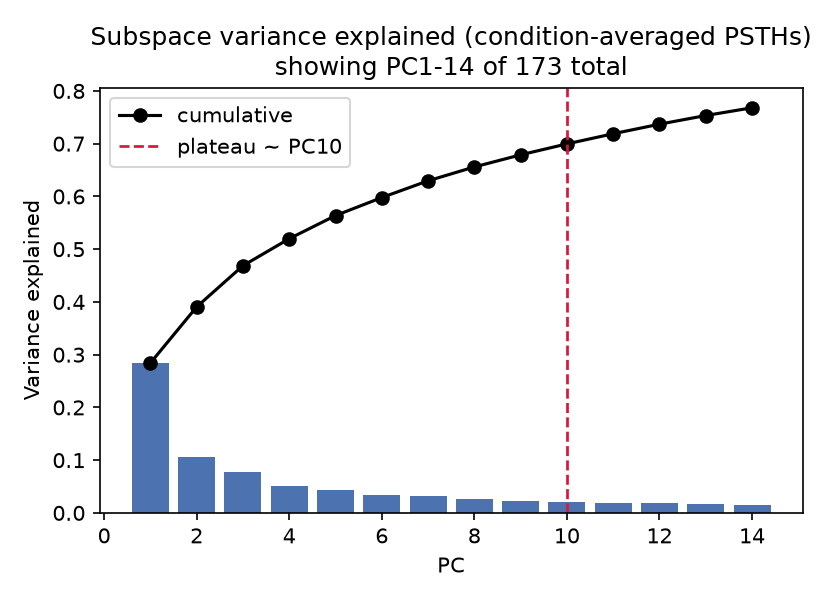

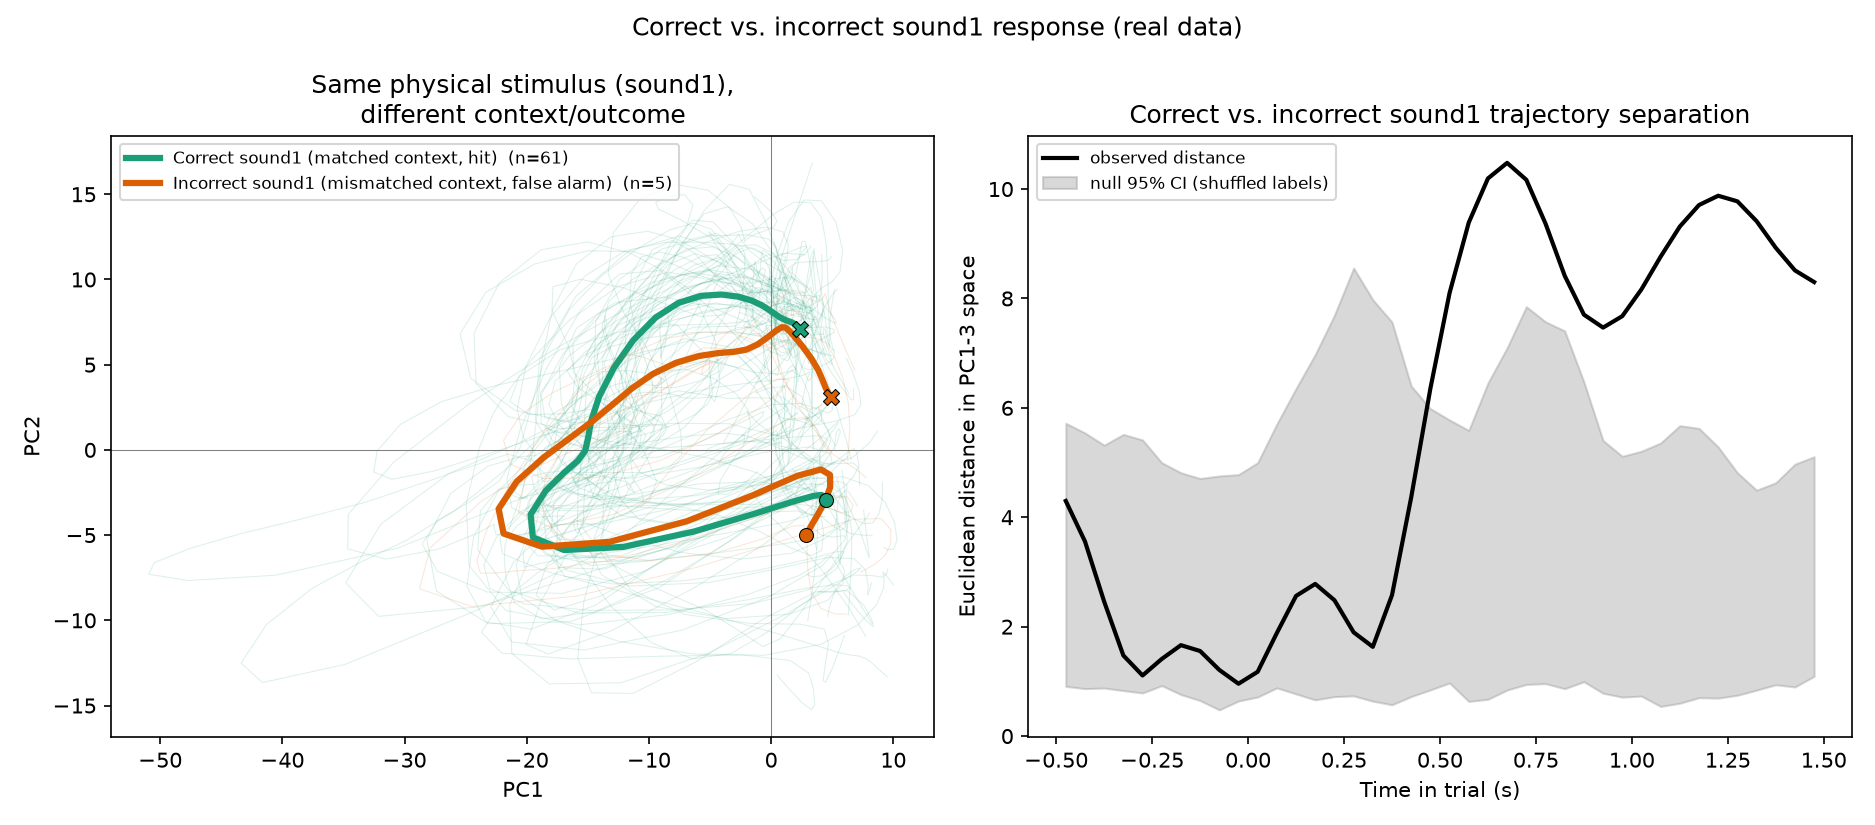

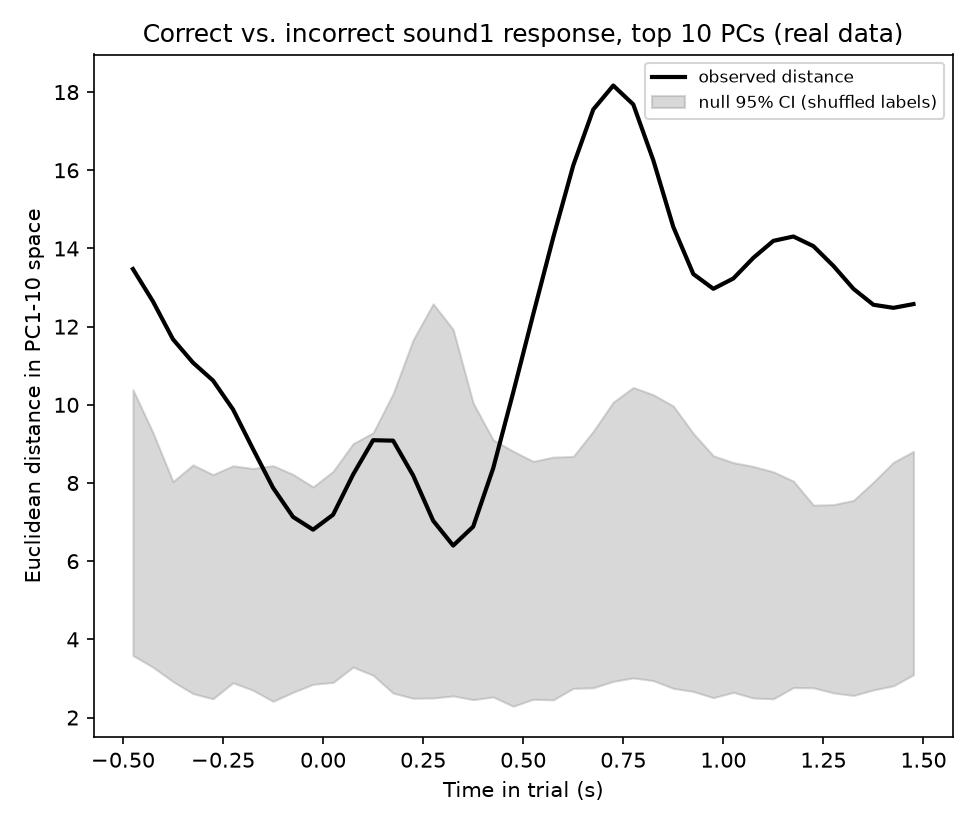

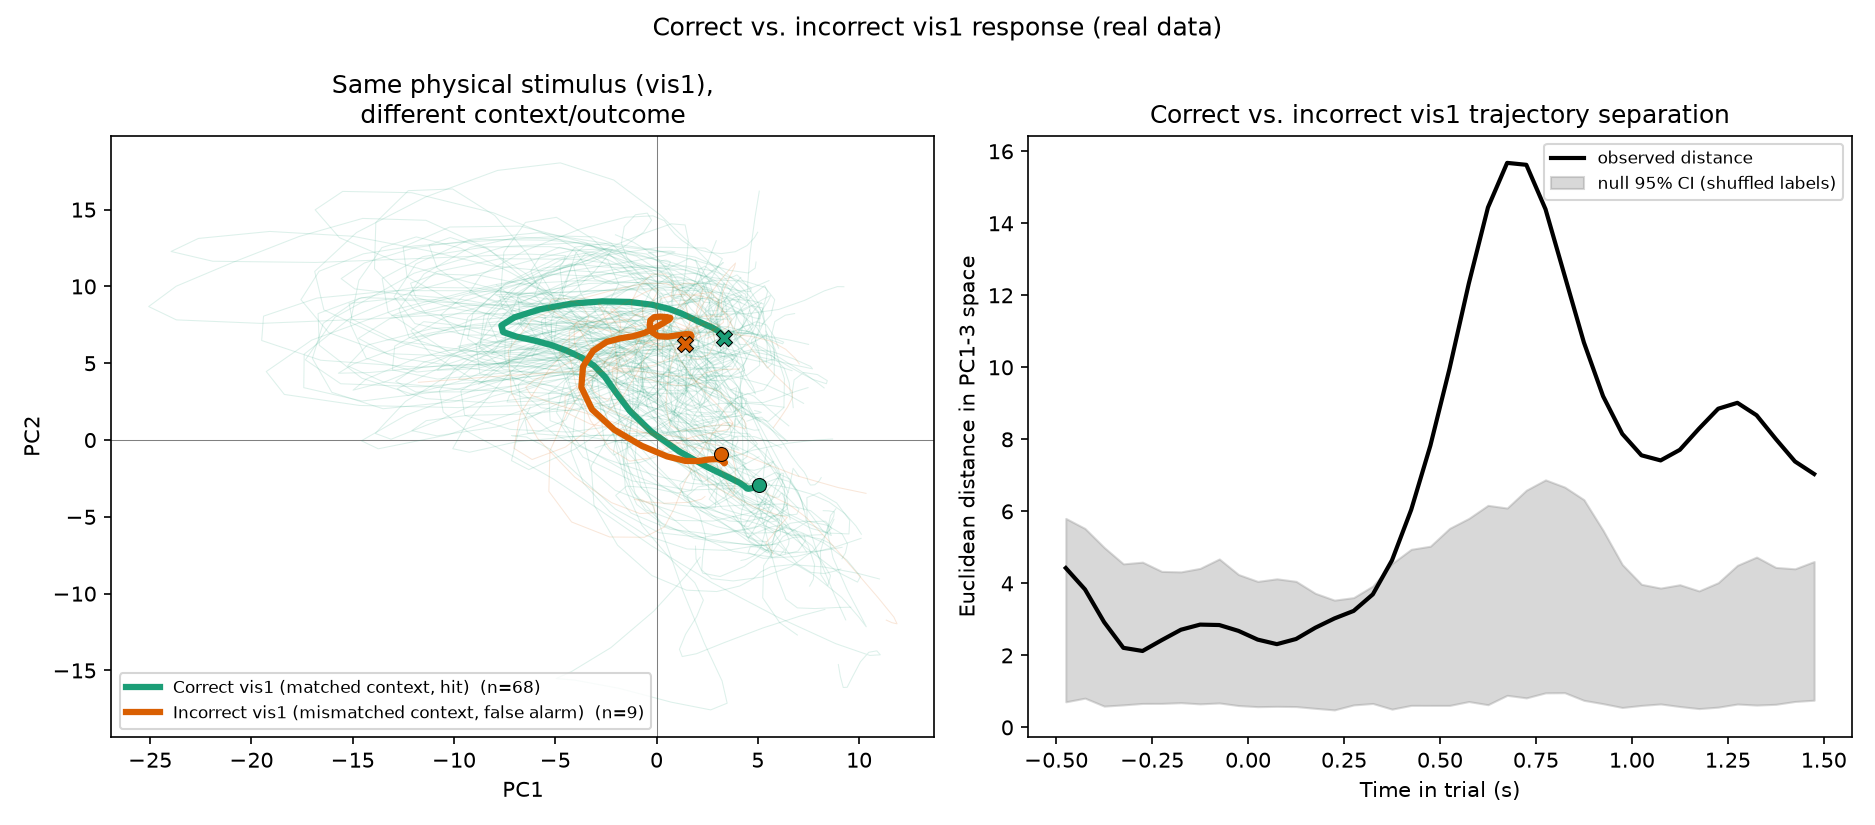

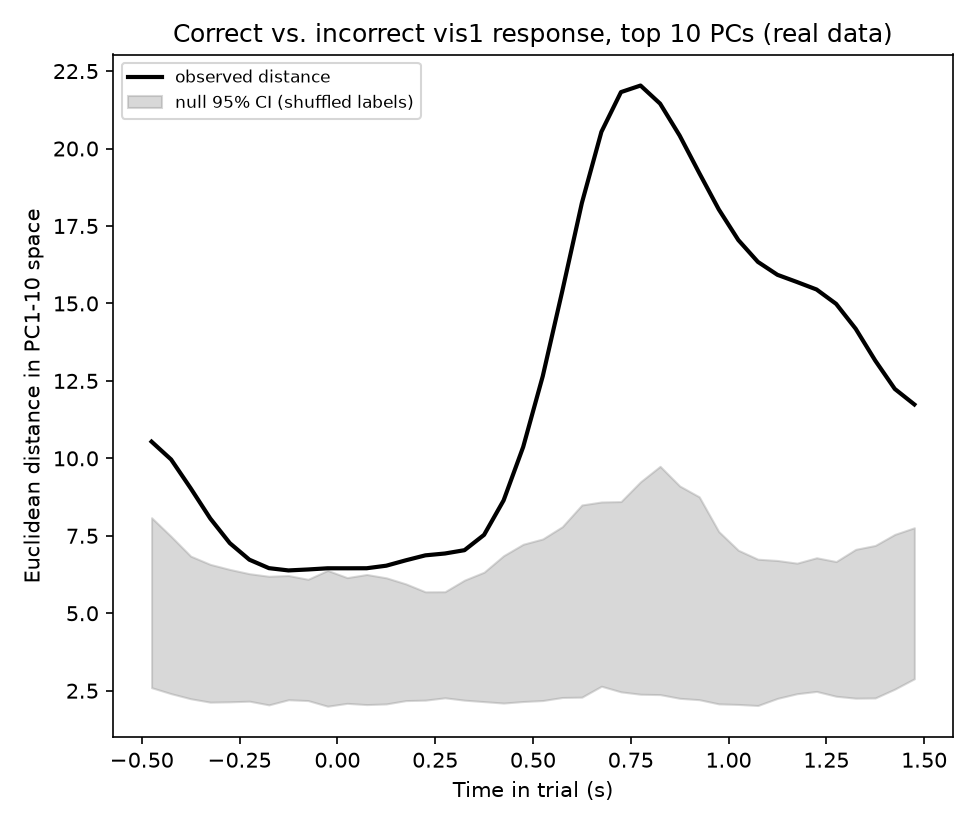

In [9]:
for f in sorted(glob.glob(f"{cfg['out_dir']}/real_subspace_*.png")):
    display(Image(filename=f))